# Series de Tiempo - Visitas Wikipedia - Equipo 8
- David Betancur
- Simón González
- Daniel Restrepo
- Jeronimo Sánchez

# 1. Entendimiento del Problema
Analizar la serie temporal de visitas a Wikipedia

# 2. Enfoque Analítico
Modelar la variable `y` con técnicas de series de tiempo

# 3. Requerimiento de Datos
Serie histórica de visitas (`y`)

# 4. Recolección de Datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.model_selection import TimeSeriesFold, grid_search_forecaster
from skforecast.deep_learning import ForecasterRnn, create_and_compile_model

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error


from statsmodels.tsa.statespace.sarimax import SARIMAX


from keras.callbacks import EarlyStopping

import warnings

warnings.filterwarnings("ignore")


set_dark_theme()


c:\Users\DELL\Documents\DAVID\Universidad\Semestre 8\ComputacionCientifica\compCientEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SMOOTH_SERIES = True
SMOOTHING_METHOD = "moving_average"
SMOOTHING_ALPHA = 0.25
SMOOTHING_WINDOW = 7

In [3]:
data = fetch_dataset(name="wikipedia_visits")
data.index.name = "datetime"

print(f"Forma del dataset: {data.shape}")
print(f"Período: {data.index.min()} a {data.index.max()}")
print(f"Valores nulos: {data['y'].isna().sum()}")
data.head()

╭──────────────────────────────── wikipedia_visits ────────────────────────────────╮
│ Description:                                                                     │
│ Log daily page views for the Wikipedia page for Peyton Manning. Scraped data     │
│ using the Wikipediatrend package in R.                                           │
│                                                                                  │
│ Source:                                                                          │
│ https://github.com/facebook/prophet/blob/{version}/examples/example_wp_log_peyto │
│ n_manning.csv                                                                    │
│                                                                                  │
│ URL:                                                                             │
│ https://raw.githubusercontent.com/skforecast/skforecast-                         │
│ datasets/main/data/wikipedia_visits.csv                                          │
│                                                                                  │
│ Shape: 2964 rows x 1 columns                                                     │
╰──────────────────────────────────────────────────────────────────────────────────╯

Forma del dataset: (2964, 1)
Período: 2007-12-10 00:00:00 a 2016-01-20 00:00:00
Valores nulos: 59


,y
datetime,
2007-12-10,9.590761
2007-12-11,8.519590
2007-12-12,8.183677
2007-12-13,8.072467
2007-12-14,7.893572


# 5. Exploración de Datos
- Identificar patrones de la serie
- Evaluar estacionalidad

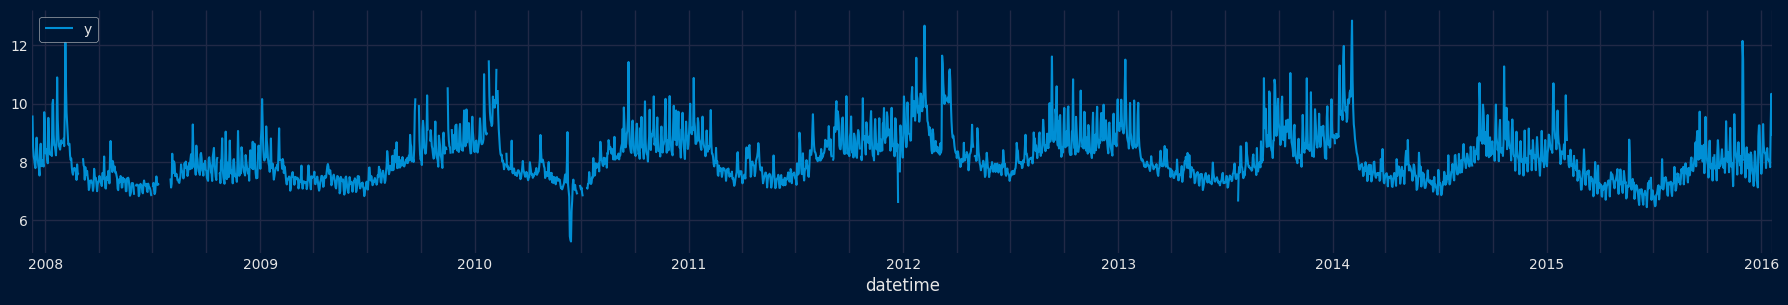

In [4]:
fig, ax = plt.subplots(figsize=(20, 3))
data.plot(ax=ax)
ax.legend()
plt.show()

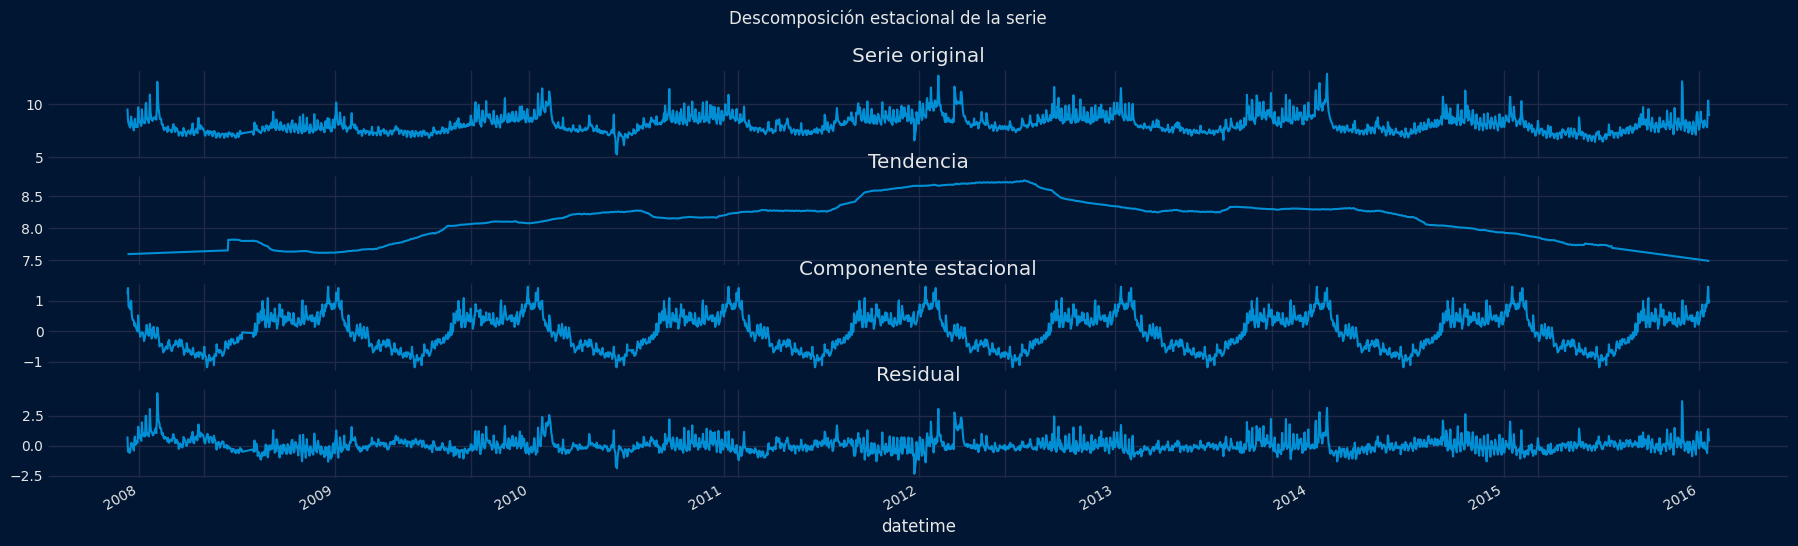

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

data_clean = data["y"].dropna()

res_decompose = seasonal_decompose(
    data_clean, model="additive", extrapolate_trend="freq", period=365
)

fig, ax = plt.subplots(4, 1, figsize=(20, 6), sharex=True)

res_decompose.observed.plot(ax=ax[0])
ax[0].set_title("Serie original")

res_decompose.trend.plot(ax=ax[1])
ax[1].set_title("Tendencia")

res_decompose.seasonal.plot(ax=ax[2])
ax[2].set_title("Componente estacional")

res_decompose.resid.plot(ax=ax[3])
ax[3].set_title("Residual")

fig.suptitle("Descomposición estacional de la serie")
plt.show()

# **6. Preparación de Datos**
- Imputación de valores nulos con método lineal.
- Análisis de autocorrelación y autocorrelación parcial.
- División en entrenamiento y prueba.

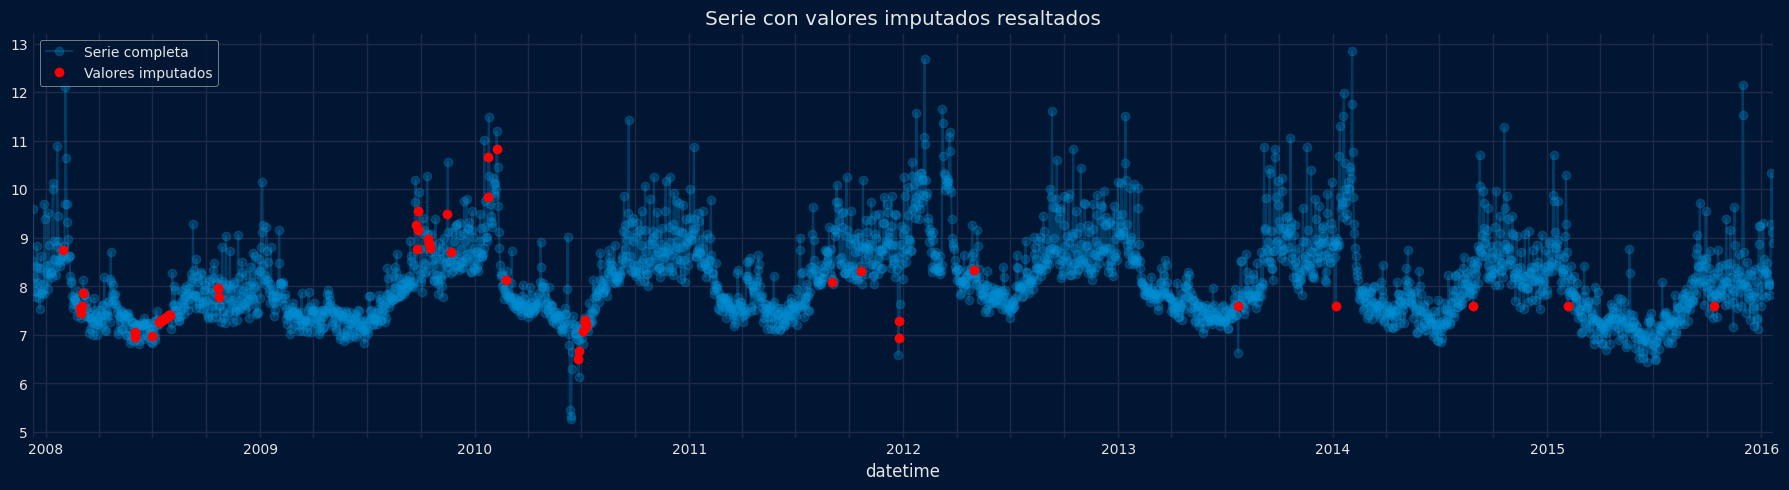

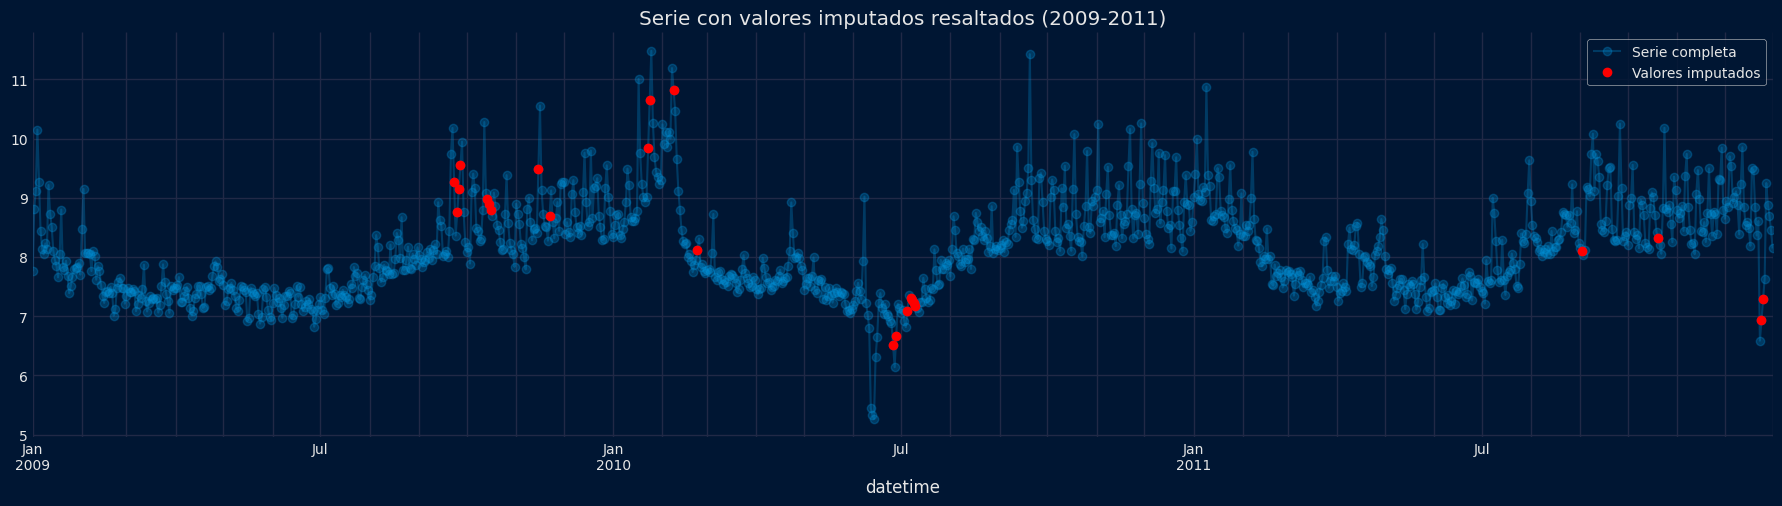

np.int64(0)

In [6]:
null_mask = data["y"].isna()

if "test_size" not in locals():
    test_size = 912
train_end_pos = len(data) - test_size

data_train_raw = data.iloc[:train_end_pos].copy()
data_test_raw = data.iloc[train_end_pos:].copy()

data_train_raw["y"] = data_train_raw["y"].interpolate(method="linear")
data_train_raw["y"] = data_train_raw["y"].ffill().bfill()

data_test_raw["y"] = data_test_raw["y"].fillna(data_train_raw["y"].iloc[-1])
data_test_raw["y"] = data_test_raw["y"].interpolate(method="linear")
data_test_raw["y"] = data_test_raw["y"].ffill()

data_train_interpolated = data_train_raw["y"].copy()
data_test_interpolated = data_test_raw["y"].copy()
data["y_interpolated"] = pd.concat([data_train_interpolated, data_test_interpolated])

plt.figure(figsize=(20, 5))
data["y_interpolated"].plot(marker="o", label="Serie completa", alpha=0.3)
data["y_interpolated"][null_mask].plot(
    color="red", marker="o", ls="", label="Valores imputados"
)
plt.title("Serie con valores imputados resaltados")
plt.legend()
plt.show()

plt.figure(figsize=(20, 5))
data["y_interpolated"].loc["2009":"2011"].plot(
    marker="o", label="Serie completa", alpha=0.3
)
data["y_interpolated"][null_mask].loc["2009":"2011"].plot(
    color="red", marker="o", ls="", label="Valores imputados"
)
plt.title("Serie con valores imputados resaltados (2009-2011)")
plt.legend()
plt.show()

data["y_interpolated"].isna().sum()


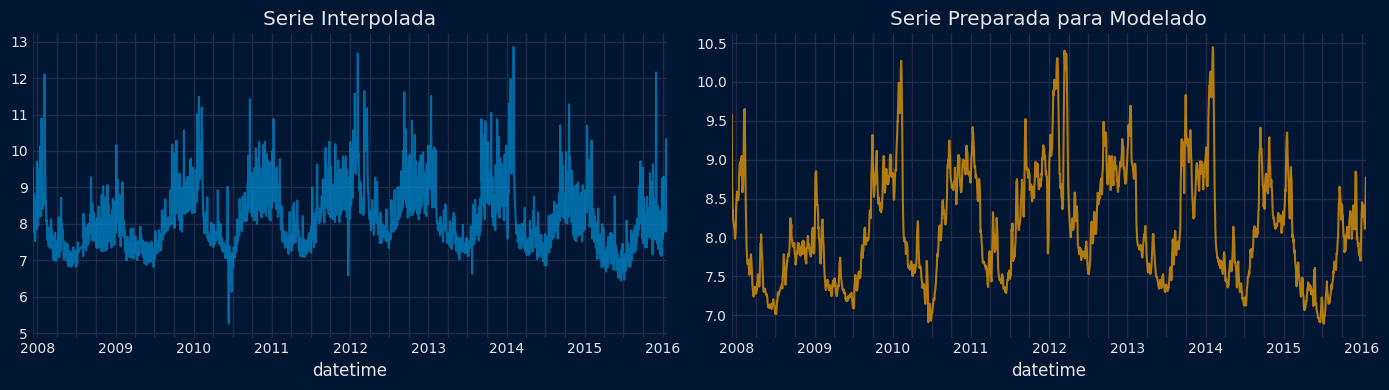

Percentiles 1% y 99% (train): 6.89 / 10.68
Rango interpolado (sin suavizar): [5.26, 12.85]
Rango final usado en el modelado: [6.89, 10.45]
Suavizado aplicado: MOVING_AVERAGE


In [7]:
train_lower = data_train_interpolated.quantile(0.01)
train_upper = data_train_interpolated.quantile(0.99)

data_train_processed = data_train_interpolated.clip(
    lower=train_lower, upper=train_upper
)
data_test_processed = data_test_interpolated.clip(lower=train_lower, upper=train_upper)

data_processed = pd.concat([data_train_processed, data_test_processed])
data["y_processed_raw"] = data_processed.copy()

data_processed_smoothed = data_processed.copy()
if SMOOTH_SERIES:
    method = SMOOTHING_METHOD.lower()
    if method == "ewma":
        data_processed_smoothed = data_processed.ewm(
            alpha=SMOOTHING_ALPHA, adjust=False
        ).mean()
    elif method == "moving_average":
        data_processed_smoothed = data_processed.rolling(
            window=SMOOTHING_WINDOW, min_periods=1
        ).mean()
    else:
        raise ValueError(f"Método de suavizado no soportado: {SMOOTHING_METHOD}")

    data["y_processed_smoothed"] = data_processed_smoothed.copy()
else:
    data["y_processed_smoothed"] = data_processed_smoothed.copy()

if SMOOTH_SERIES:
    data["y_processed"] = data_processed_smoothed.copy()
else:
    data["y_processed"] = data_processed.copy()

final_processed = data["y_processed"]
data_train_processed = final_processed.iloc[:train_end_pos].copy()
data_test_processed = final_processed.iloc[train_end_pos:].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
data["y_interpolated"].plot(ax=axes[0], title="Serie Interpolada", alpha=0.7)
data["y_processed"].plot(
    ax=axes[1], title="Serie Preparada para Modelado", alpha=0.7, color="orange"
)
plt.tight_layout()
plt.show()

print(f"Percentiles 1% y 99% (train): {train_lower:.2f} / {train_upper:.2f}")
print(
    f"Rango interpolado (sin suavizar): [{data['y_interpolated'].min():.2f}, {data['y_interpolated'].max():.2f}]"
)
print(
    f"Rango final usado en el modelado: [{data['y_processed'].min():.2f}, {data['y_processed'].max():.2f}]"
)
estado_suavizado = (
    f"{SMOOTHING_METHOD.upper()}" if SMOOTH_SERIES else "No (serie original)"
)
print(f"Suavizado aplicado: {estado_suavizado}")


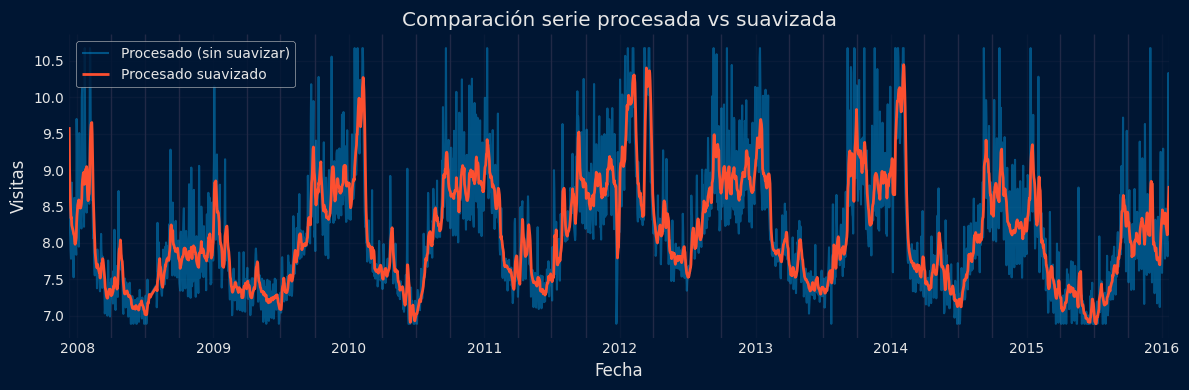

In [8]:
plt.figure(figsize=(12, 4))
data["y_processed_raw"].plot(label="Procesado (sin suavizar)", alpha=0.5)
if SMOOTH_SERIES:
    data["y_processed"].plot(label="Procesado suavizado", linewidth=2)
else:
    data["y_processed"].plot(label="Procesado", linewidth=2)
plt.title("Comparación serie procesada vs suavizada")
plt.xlabel("Fecha")
plt.ylabel("Visitas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
from statsmodels.tsa.stattools import adfuller

data_clean = data["y_processed"].dropna()

print("Test de estacionariedad de la serie (y_processed)")
adfuller_result = adfuller(data_clean)
print(f"Estadístico ADF: {adfuller_result[0]}")
print(f"Valor p: {adfuller_result[1]}")

if adfuller_result[1] < 0.05:
    print("Conclusión: La serie es estacionaria (se rechaza H0)")
else:
    print("Conclusión: La serie NO es estacionaria (no se rechaza H0)")


Test de estacionariedad de la serie (y_processed)
Estadístico ADF: -3.747360875997435
Valor p: 0.003494206656819807
Conclusión: La serie es estacionaria (se rechaza H0)


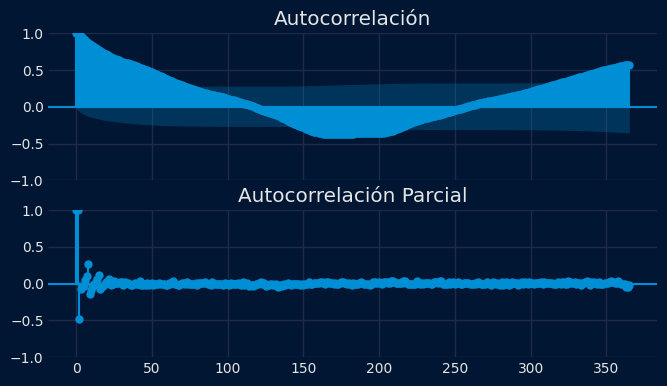

In [10]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(7, 4), sharex=True)
plot_acf(data["y_processed"], ax=ax[0], lags=365, alpha=0.05)
ax[0].set_title("Autocorrelación")
plot_pacf(data["y_processed"], ax=ax[1], lags=365, alpha=0.05)
ax[1].set_title("Autocorrelación Parcial")
plt.show()


Train: 2052 observaciones (2007-12-10 00:00:00 a 2013-07-22 00:00:00)
Test: 912 observaciones (2013-07-23 00:00:00 a 2016-01-20 00:00:00)
Proporción train/test: 69.2% / 30.8%


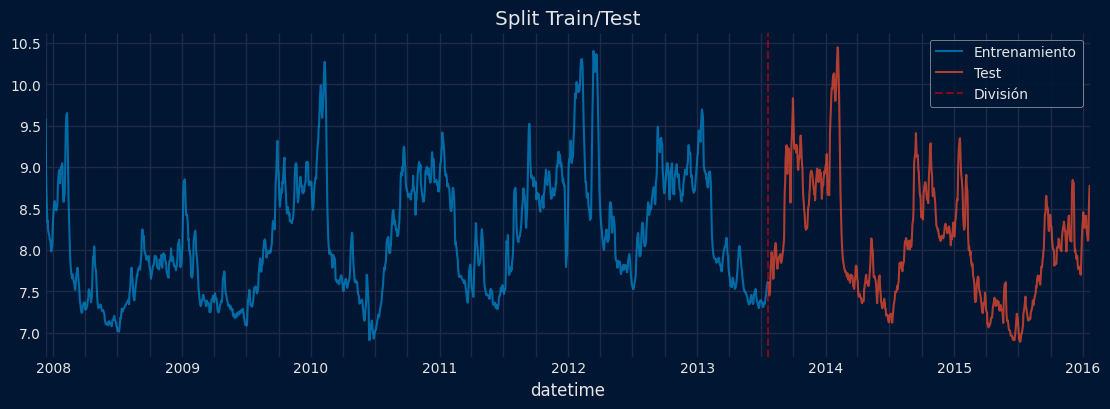

In [11]:
test_size = 365

data_train = data_train_processed.copy()
data_test = data_test_processed.copy()
split_date = data_train.index.max()

print(
    f"Train: {len(data_train)} observaciones ({data_train.index.min()} a {data_train.index.max()})"
)
print(
    f"Test: {len(data_test)} observaciones ({data_test.index.min()} a {data_test.index.max()})"
)
print(
    f"Proporción train/test: {len(data_train) / len(data):.1%} / {len(data_test) / len(data):.1%}"
)

# Visualización
plt.figure(figsize=(12, 4))
data_train.plot(label="Entrenamiento", alpha=0.7)
data_test.plot(label="Test", alpha=0.7)
plt.axvline(split_date, color="red", linestyle="--", alpha=0.5, label="División")
plt.legend()
plt.title("Split Train/Test")
plt.show()


# 7. Modelado
- SARIMAX
- LR
- DT
- RF
- RNN

## 7.1 SARIMAX

In [12]:
def crear_features_estacionalidad(n_days, start_day=0):
    dias = np.arange(start_day, start_day + n_days)

    # Ciclo anual
    dia_año = dias % 365
    sin_anual = np.sin(2 * np.pi * dia_año / 365)
    cos_anual = np.cos(2 * np.pi * dia_año / 365)

    # Armonicos para sub-patrones
    sin_semestral = np.sin(2 * np.pi * dia_año / (365 / 2))
    cos_semestral = np.cos(2 * np.pi * dia_año / (365 / 2))

    return np.column_stack([sin_anual, cos_anual, sin_semestral, cos_semestral])


exog_train = crear_features_estacionalidad(len(data_train))
exog_test = crear_features_estacionalidad(len(data_test), start_day=len(data_train))


modelo_sarimax = SARIMAX(
    endog=data_train,
    exog=exog_train,
    order=(3, 0, 3),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)

modelo_sarimax = modelo_sarimax.fit(disp=True, maxiter=500, method="lbfgs")

pred_sarimax = modelo_sarimax.get_forecast(
    steps=len(data_test), exog=exog_test
).predicted_mean
pred_sarimax.name = "predicciones_sarimax"

mae_sarimax = mean_absolute_error(data_test, pred_sarimax)
rmse_sarimax = np.sqrt(mean_squared_error(data_test, pred_sarimax))

print(f"\nSARIMAX - MAE: {mae_sarimax:.4f} | RMSE: {rmse_sarimax:.4f}")


SARIMAX - MAE: 0.7607 | RMSE: 1.0113


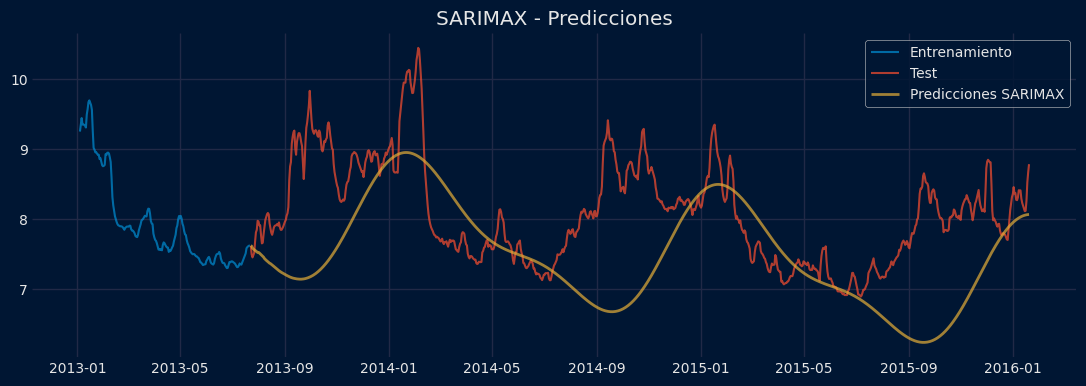

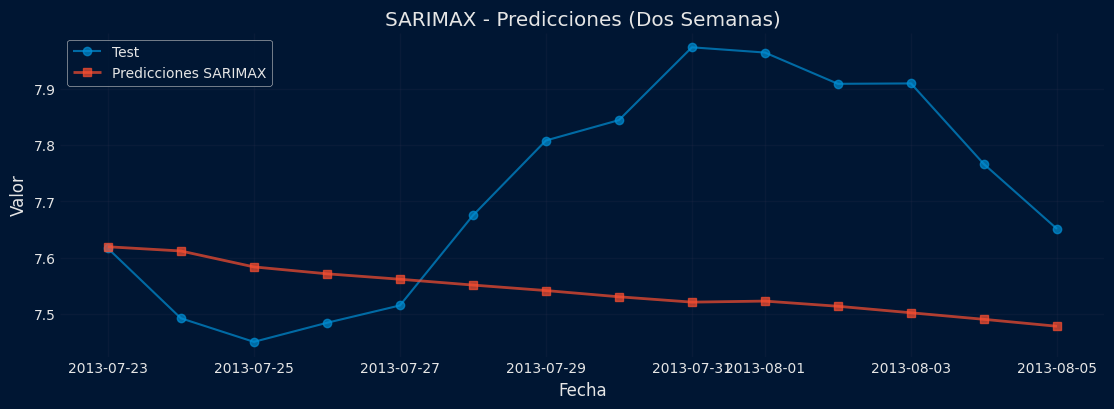

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(data_train[-200:], label="Entrenamiento", alpha=0.7)
plt.plot(data_test, label="Test", alpha=0.7)
plt.plot(pred_sarimax, label="Predicciones SARIMAX", alpha=0.7, linewidth=2)
plt.legend()
plt.title("SARIMAX - Predicciones")
plt.show()

# Zoom en 1 semana de predicciones
plt.figure(figsize=(12, 4))
plt.plot(data_test[:14], label="Test", alpha=0.7, marker="o")
plt.plot(
    pred_sarimax[:14], label="Predicciones SARIMAX", alpha=0.7, linewidth=2, marker="s"
)
plt.legend()
plt.title("SARIMAX - Predicciones (Dos Semanas)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

## 7.2 FR - Linear Regression

In [14]:
forecaster_lr = ForecasterRecursive(
    regressor=LinearRegression(),
    lags=[1, 2, 3, 7, 14, 21, 28, 365, 364, 366],
    window_features=RollingFeatures(stats=["mean", "std"], window_sizes=[7, 14]),
)

forecaster_lr.fit(y=data_train, store_in_sample_residuals=True)
pred_lr = forecaster_lr.predict(steps=len(data_test))

mae_lr = mean_absolute_error(data_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(data_test, pred_lr))

print(f"Regresión Lineal - MAE: {mae_lr:.4f} | RMSE: {rmse_lr:.4f}")

Regresión Lineal - MAE: 0.9050 | RMSE: 1.0693


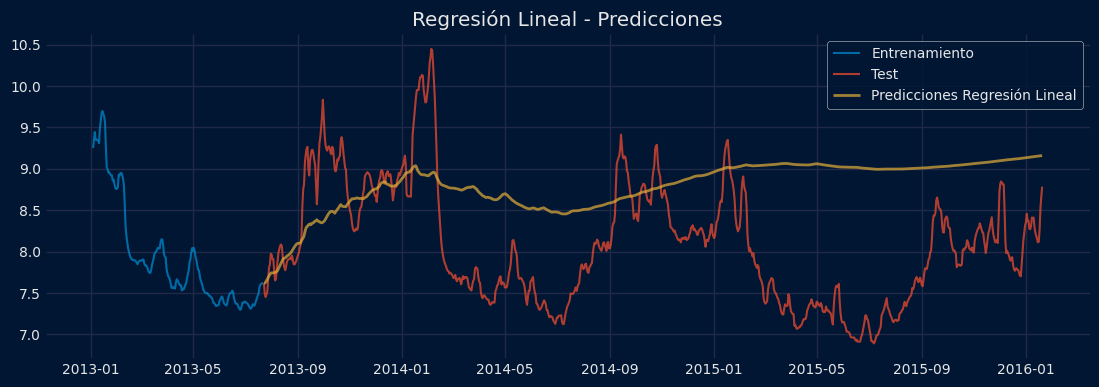

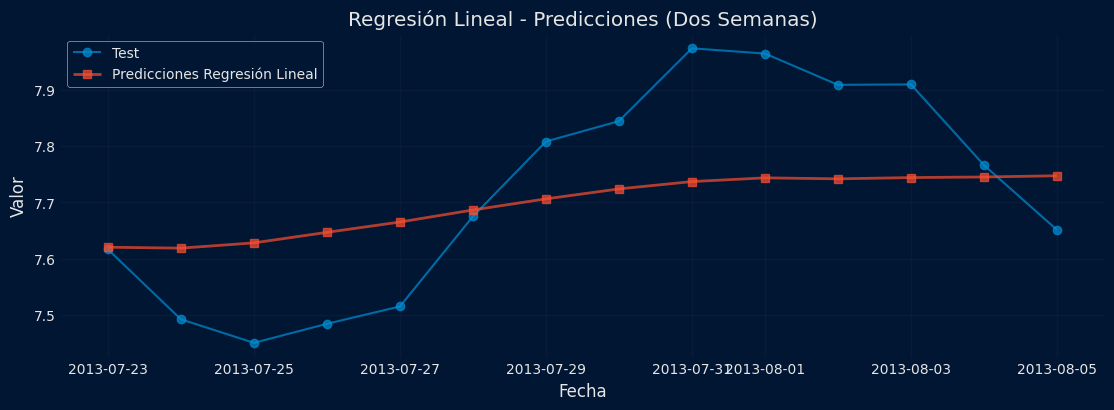

In [15]:
plt.figure(figsize=(12, 4))
plt.plot(data_train[-200:], label="Entrenamiento", alpha=0.7)
plt.plot(data_test, label="Test", alpha=0.7)
plt.plot(pred_lr, label="Predicciones Regresión Lineal", alpha=0.7, linewidth=2)
plt.legend()
plt.title("Regresión Lineal - Predicciones")
plt.show()

# Zoom en 1 semana de predicciones
plt.figure(figsize=(12, 4))
plt.plot(data_test[:14], label="Test", alpha=0.7, marker="o")
plt.plot(
    pred_lr[:14],
    label="Predicciones Regresión Lineal",
    alpha=0.7,
    linewidth=2,
    marker="s",
)
plt.legend()
plt.title("Regresión Lineal - Predicciones (Dos Semanas)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

## 7.3 FR - Decision Tree

In [16]:
forecaster_dt = ForecasterRecursive(
    regressor=DecisionTreeRegressor(random_state=42), lags=7
)

lags_grid = {
    "lags_7": 7,
    "lags_anual": [1, 7, 365, 364, 366],
    "lags_completo": [1, 7, 14, 30, 365, 364, 366],
}

param_grid = {
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 10],
    "criterion": ["squared_error"],
}

cv = TimeSeriesFold(
    steps=7,
    initial_train_size=len(data_train) - 7 * 10,
    refit=False,
)

print("Iniciando Grid Search para Árbol de Decisión...")
results_dt = grid_search_forecaster(
    forecaster=forecaster_dt,
    y=data_train,
    param_grid=param_grid,
    lags_grid=lags_grid,
    cv=cv,
    metric="mean_absolute_error",
    return_best=True,
    n_jobs=-1,
    verbose=False,
    show_progress=True,
)

print(results_dt.head(3))

pred_dt = forecaster_dt.predict(steps=len(data_test))

mae_dt = mean_absolute_error(data_test, pred_dt)
rmse_dt = np.sqrt(mean_squared_error(data_test, pred_dt))

print(f"\nDT - MAE: {mae_dt:.4f} | RMSE: {rmse_dt:.4f}")

Iniciando Grid Search para Árbol de Decisión...


lags grid: 100%|██████████| 3/3 [00:10<00:00,  3.37s/it]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2 3 4 5 6 7] 
  Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 10}
  Backtesting metric: 0.0747674941810903
                    lags lags_label  \
0  [1, 2, 3, 4, 5, 6, 7]     lags_7   
1  [1, 2, 3, 4, 5, 6, 7]     lags_7   
2  [1, 2, 3, 4, 5, 6, 7]     lags_7   

                                              params  mean_absolute_error  \
0  {'criterion': 'squared_error', 'max_depth': 10...             0.074767   
1  {'criterion': 'squared_error', 'max_depth': 20...             0.074767   
2  {'criterion': 'squared_error', 'max_depth': No...             0.074767   

       criterion  max_depth  min_samples_leaf  
0  squared_error       10.0                10  
1  squared_error       20.0                10  
2  squared_error        NaN                10  

DT - MAE: 0.5879 | RMSE: 0.7468


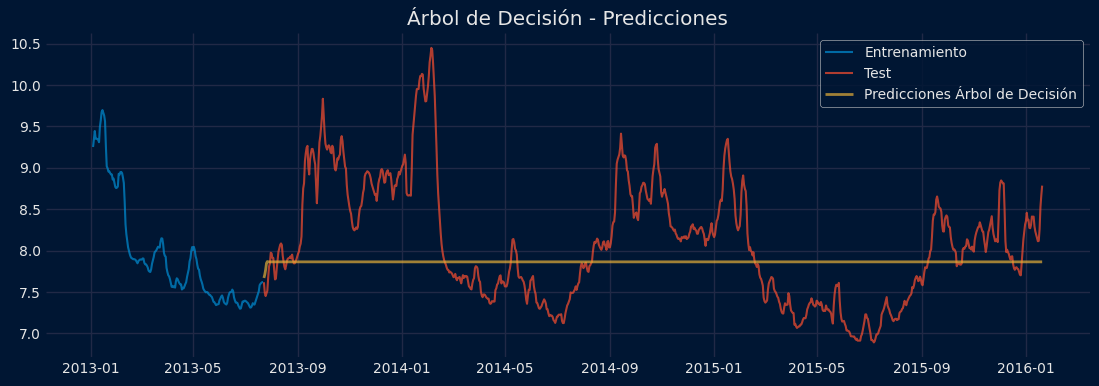

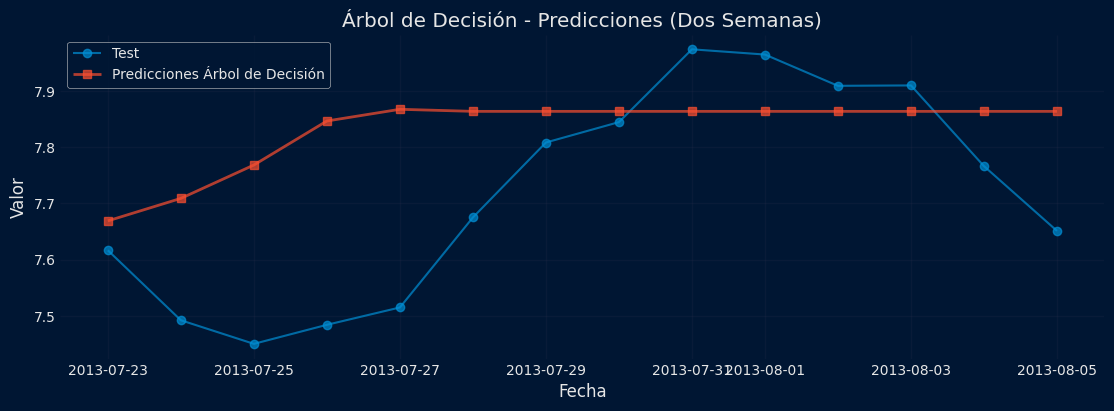

In [17]:
plt.figure(figsize=(12, 4))
plt.plot(data_train[-200:], label="Entrenamiento", alpha=0.7)
plt.plot(data_test, label="Test", alpha=0.7)
plt.plot(pred_dt, label="Predicciones Árbol de Decisión", alpha=0.7, linewidth=2)
plt.legend()
plt.title("Árbol de Decisión - Predicciones")
plt.show()

# Zoom en 1 semana de predicciones
plt.figure(figsize=(12, 4))
plt.plot(data_test[:14], label="Test", alpha=0.7, marker="o")
plt.plot(
    pred_dt[:14],
    label="Predicciones Árbol de Decisión",
    alpha=0.7,
    linewidth=2,
    marker="s",
)
plt.legend()
plt.title("Árbol de Decisión - Predicciones (Dos Semanas)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()


## 7.4 FR - Random Forest

In [18]:
forecaster_rf = ForecasterRecursive(
    regressor=RandomForestRegressor(random_state=42, n_jobs=-1), lags=7
)

lags_grid = {
    "lags_7": 7,
    "lags_14": 14,
    "lags_anual": [1, 7, 365, 364, 366],
    "lags_completo": [1, 7, 14, 30, 365, 364, 366],
}

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt", 0.5],
    "criterion": ["squared_error", "absolute_error"],
}


cv = TimeSeriesFold(steps=7, initial_train_size=len(data_train) - 7 * 10, refit=False)

results_rf = grid_search_forecaster(
    forecaster=forecaster_rf,
    y=data_train,
    param_grid=param_grid,
    lags_grid=lags_grid,
    cv=cv,
    metric="mean_absolute_error",
    return_best=True,
    n_jobs=-1,
    verbose=False,
    show_progress=True,
)

print(results_rf.head(3))


pred_rf = forecaster_rf.predict(steps=len(data_test))

mae_rf = mean_absolute_error(data_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(data_test, pred_rf))

print(f"\nRF - MAE: {mae_rf:.4f} | RMSE: {rmse_rf:.4f}")


lags grid: 100%|██████████| 4/4 [10:16<00:00, 154.18s/it]


`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2 3 4 5 6 7] 
  Parameters: {'criterion': 'absolute_error', 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
  Backtesting metric: 0.06917141189452754
                                              lags lags_label  \
0                            [1, 2, 3, 4, 5, 6, 7]     lags_7   
1  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]    lags_14   
2  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]    lags_14   

                                              params  mean_absolute_error  \
0  {'criterion': 'absolute_error', 'max_depth': 1...             0.069171   
1  {'criterion': 'absolute_error', 'max_depth': N...             0.069480   
2  {'criterion': 'absolute_error', 'max_depth': 2...             0.069480   

        criterion  max_depth max_features  min_samples_leaf  \
0  absolute_error       10.0          0.5                 

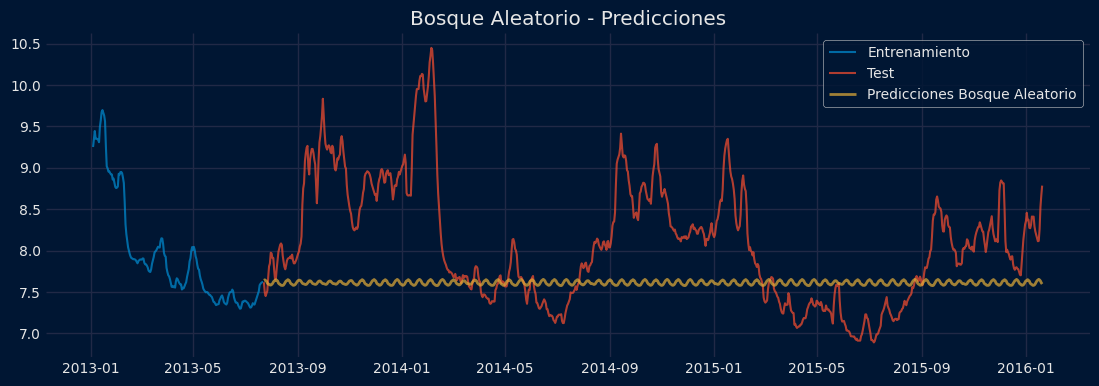

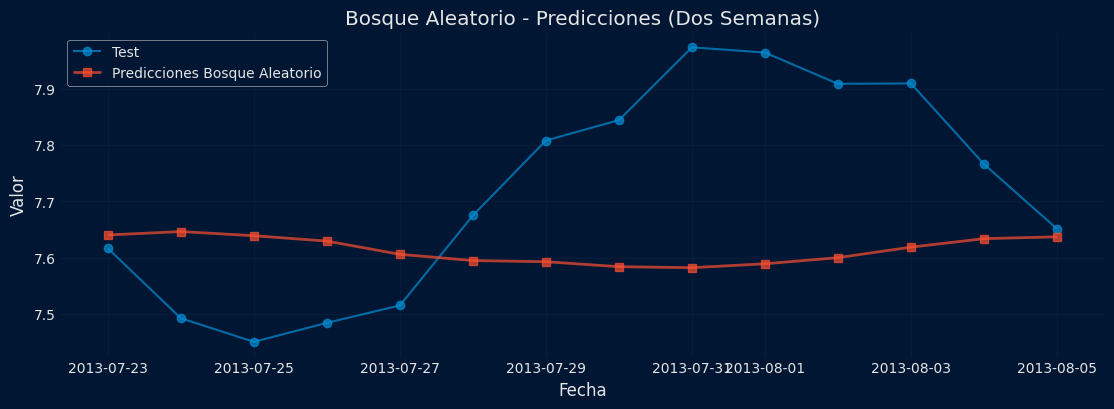

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(data_train[-200:], label="Entrenamiento", alpha=0.7)
plt.plot(data_test, label="Test", alpha=0.7)
plt.plot(pred_rf, label="Predicciones Bosque Aleatorio", alpha=0.7, linewidth=2)
plt.legend()
plt.title("Bosque Aleatorio - Predicciones")
plt.show()

# Zoom en 1 semana de predicciones
plt.figure(figsize=(12, 4))
plt.plot(data_test[:14], label="Test", alpha=0.7, marker="o")
plt.plot(
    pred_rf[:14],
    label="Predicciones Bosque Aleatorio",
    alpha=0.7,
    linewidth=2,
    marker="s",
)
plt.legend()
plt.title("Bosque Aleatorio - Predicciones (Dos Semanas)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

## 7.5 RNN

In [20]:
data_train_df = pd.DataFrame(data_train)
data_train_df.columns = ["y_processed"]
data_test_df = pd.DataFrame(data_test)
data_test_df.columns = ["y_processed"]

train_size_rnn = int(len(data_train) * 0.85)
data_train_rnn = data_train_df.iloc[:train_size_rnn]
data_val_rnn = data_train_df.iloc[train_size_rnn:]

print(f"RNN Train: {len(data_train_rnn)} | RNN Val: {len(data_val_rnn)}")

RNN Train: 1744 | RNN Val: 308


In [21]:
from skforecast.model_selection import backtesting_forecaster_multiseries

model_rnn = create_and_compile_model(
    series=data_train_df,
    levels=["y_processed"],
    lags=60,
    steps=7,
    recurrent_layer="LSTM",
    recurrent_units=128,
    dense_units=64,
)

model_rnn.summary()

keras version: 3.11.3
Using backend: tensorflow
tensorflow version: 2.20.0



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ series_input (InputLayer)       │ (None, 60, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense_td_layer (Dense)   │ (None, 7)              │           455 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 1)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,271 (294.03 KB)

 Trainable params: 75,271 (294.03 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
forecaster_rnn = ForecasterRnn(
    regressor=model_rnn,
    levels=["y_processed"],
    lags=60,
    transformer_series=MinMaxScaler(),
    fit_kwargs={
        "epochs": 100,
        "batch_size": 64,
        "callbacks": [
            EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
        ],
        "series_val": data_val_rnn,
    },
)

forecaster_rnn.fit(data_train_rnn)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 0.0608 - val_loss: 0.0102
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0119 - val_loss: 0.0067
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0102 - val_loss: 0.0063
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0091 - val_loss: 0.0056
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0085 - val_loss: 0.0053
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0082 - val_loss: 0.0051
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0074 - val_loss: 0.0045
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0071 - val_loss: 0.0043
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0071 - val_loss: 0.0042
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0074 - val_loss: 0.0060
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.0068 - val_loss: 0.0041
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step

In [23]:
# Concatenar train y test para backtesting
full_data = pd.concat([data_train_df, data_test_df])
full_data = full_data.sort_index()
full_data = full_data[~full_data.index.duplicated(keep="first")]
full_data = full_data.asfreq("D")
full_data = full_data.ffill()


In [24]:
from skforecast.model_selection import TimeSeriesFold

cv_test = TimeSeriesFold(
    steps=7,
    initial_train_size=len(data_train_df),
    refit=False,
)

metrics_rnn, pred_rnn_df = backtesting_forecaster_multiseries(
    forecaster=forecaster_rnn,
    series=full_data,
    cv=cv_test,
    levels=["y_processed"],
    metric="mean_absolute_error",
)

print(metrics_rnn)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0037 - val_loss: 0.0030
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0037 - val_loss: 0.0026
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0037 - val_loss: 0.0028
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0037 - val_loss: 0.0025
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0037 - val_loss: 0.0027
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0035 - val_loss: 0.0039
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.0042 - val_loss: 0.0023
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0036 - val_loss: 0.0024
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0035 - val_loss: 0.0024
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step

100%|██████████| 131/131 [00:13<00:00,  9.85it/s]

        levels  mean_absolute_error
0  y_processed             0.153872


In [25]:
pred_rnn = pred_rnn_df["pred"]

mae_rnn = mean_absolute_error(data_test.loc[pred_rnn.index], pred_rnn)
rmse_rnn = np.sqrt(mean_squared_error(data_test.loc[pred_rnn.index], pred_rnn))

print(f"\nRNN - MAE: {mae_rnn:.4f} | RMSE: {rmse_rnn:.4f}")
print(f"Predicciones: {len(pred_rnn)}/{len(data_test)}")



RNN - MAE: 0.1539 | RMSE: 0.2253
Predicciones: 912/912


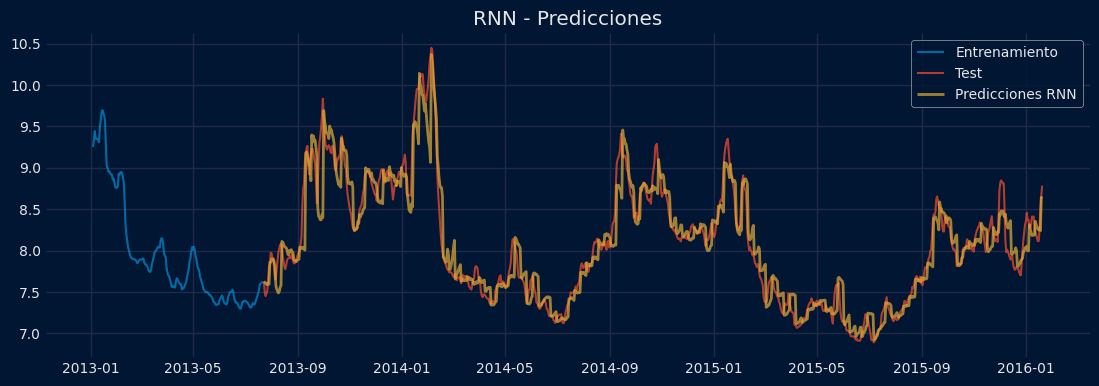

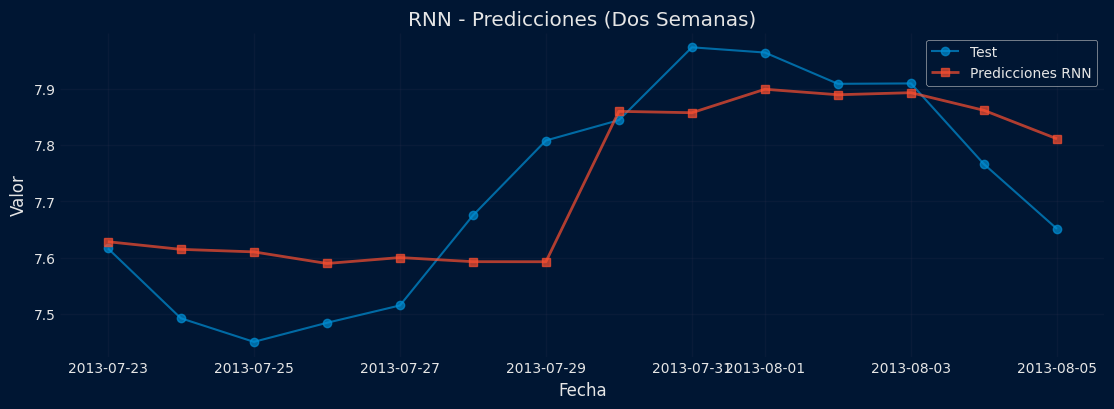

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(data_train[-200:], label="Entrenamiento", alpha=0.7)
plt.plot(data_test, label="Test", alpha=0.7)
plt.plot(pred_rnn, label="Predicciones RNN", alpha=0.7, linewidth=2)
plt.legend()
plt.title("RNN - Predicciones")
plt.show()

# Zoom en 1 semana de predicciones
plt.figure(figsize=(12, 4))
plt.plot(data_test[:14], label="Test", alpha=0.7, marker="o")
plt.plot(pred_rnn[:14], label="Predicciones RNN", alpha=0.7, linewidth=2, marker="s")
plt.legend()
plt.title("RNN - Predicciones (Dos Semanas)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
from prophet import Prophet
import pandas as pd

df_train = pd.DataFrame(
    {
        "ds": pd.date_range(start="2008-01-01", periods=len(data_train), freq="D"),
        "y": data_train.values,
    }
)

df_test = pd.DataFrame(
    {
        "ds": pd.date_range(
            start=df_train["ds"].iloc[-1] + pd.Timedelta(days=1),
            periods=len(data_test),
            freq="D",
        )
    }
)

modelo_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
)

modelo_prophet.fit(df_train)

forecast = modelo_prophet.predict(df_test)
pred_prophet = forecast["yhat"].values

mae_prophet = mean_absolute_error(data_test, pred_prophet)
rmse_prophet = np.sqrt(mean_squared_error(data_test, pred_prophet))

print(f"Prophet - MAE: {mae_prophet:.4f} | RMSE: {rmse_prophet:.4f}")

Importing plotly failed. Interactive plots will not work.
08:28:21 - cmdstanpy - INFO - Chain [1] start processing
08:28:22 - cmdstanpy - INFO - Chain [1] done processing


Prophet - MAE: 0.7460 | RMSE: 0.8241


## 7.6 Prophet

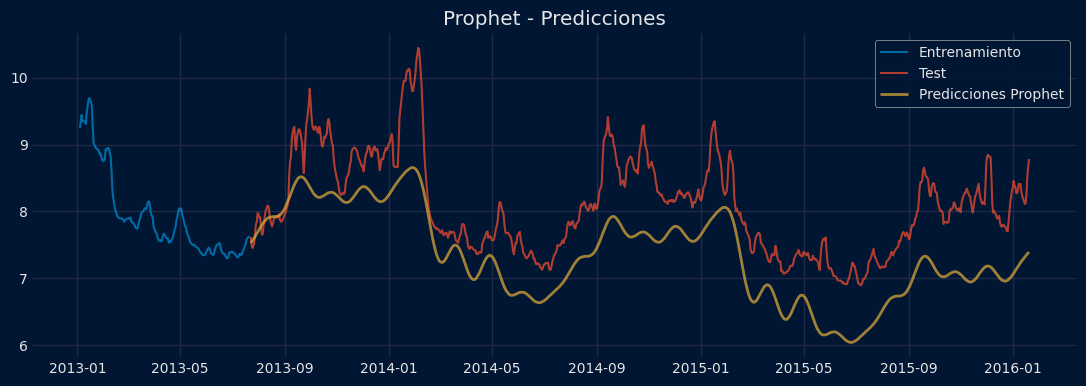

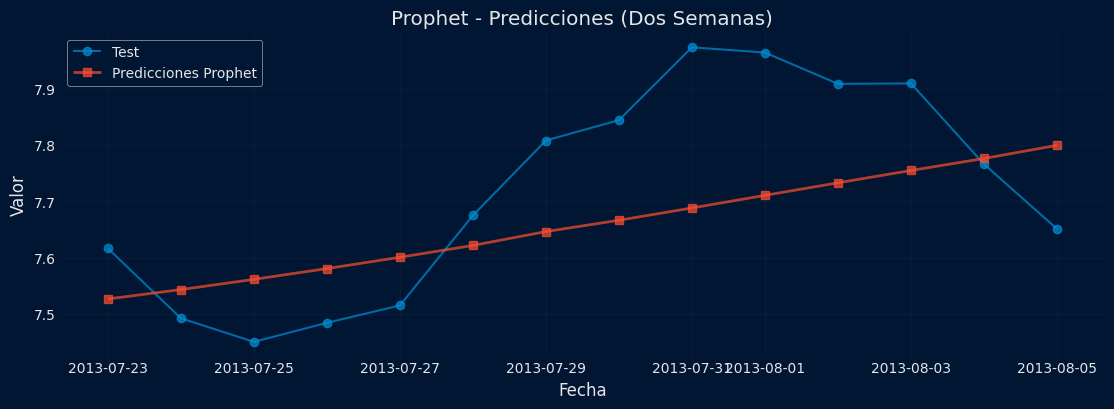

In [28]:
pred_prophet_series = pd.Series(pred_prophet, index=data_test.index)

plt.figure(figsize=(12, 4))
plt.plot(data_train[-200:], label="Entrenamiento", alpha=0.7)
plt.plot(data_test, label="Test", alpha=0.7)
plt.plot(pred_prophet_series, label="Predicciones Prophet", alpha=0.7, linewidth=2)
plt.legend()
plt.title("Prophet - Predicciones")
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(data_test[:14], label="Test", alpha=0.7, marker="o")
plt.plot(
    pred_prophet_series[:14],
    label="Predicciones Prophet",
    alpha=0.7,
    linewidth=2,
    marker="s",
)
plt.legend()
plt.title("Prophet - Predicciones (Dos Semanas)")
plt.xlabel("Fecha")
plt.ylabel("Valor")
plt.grid(True, alpha=0.3)
plt.show()

# 8. Evaluación y Comparación de Modelos

In [29]:
resultados = pd.DataFrame(
    {
        "Modelo": [
            "SARIMAX",
            "Regresión Lineal",
            "Árbol de Decisión",
            "Bosque Aleatorio",
            "RNN (LSTM)",
            "Prophet",
        ],
        "MAE": [mae_sarimax, mae_lr, mae_dt, mae_rf, mae_rnn, mae_prophet],
        "RMSE": [rmse_sarimax, rmse_lr, rmse_dt, rmse_rf, rmse_rnn, rmse_prophet],
    }
)

resultados = resultados.sort_values("MAE")

print("RESULTADOS FINALES - COMPARACIÓN DE MODELOS")

print(resultados.to_string(index=False))


RESULTADOS FINALES - COMPARACIÓN DE MODELOS
           Modelo      MAE     RMSE
       RNN (LSTM) 0.153872 0.225303
Árbol de Decisión 0.587912 0.746806
 Bosque Aleatorio 0.652538 0.854860
          Prophet 0.746029 0.824098
          SARIMAX 0.760683 1.011301
 Regresión Lineal 0.904964 1.069341


In [30]:
resultados = pd.DataFrame(
    {
        "Modelo": [
            "SARIMAX",
            "Regresión Lineal",
            "Árbol de Decisión",
            "Bosque Aleatorio",
            "RNN (LSTM)",
            "Prophet",
        ],
        "MAE": [mae_sarimax, mae_lr, mae_dt, mae_rf, mae_rnn, mae_prophet],
        "RMSE": [rmse_sarimax, rmse_lr, rmse_dt, rmse_rf, rmse_rnn, rmse_prophet],
    }
)

resultados = resultados.sort_values("MAE")

print("RESULTADOS FINALES - COMPARACIÓN DE MODELOS")

print(resultados.to_string(index=False))


RESULTADOS FINALES - COMPARACIÓN DE MODELOS
           Modelo      MAE     RMSE
       RNN (LSTM) 0.153872 0.225303
Árbol de Decisión 0.587912 0.746806
 Bosque Aleatorio 0.652538 0.854860
          Prophet 0.746029 0.824098
          SARIMAX 0.760683 1.011301
 Regresión Lineal 0.904964 1.069341


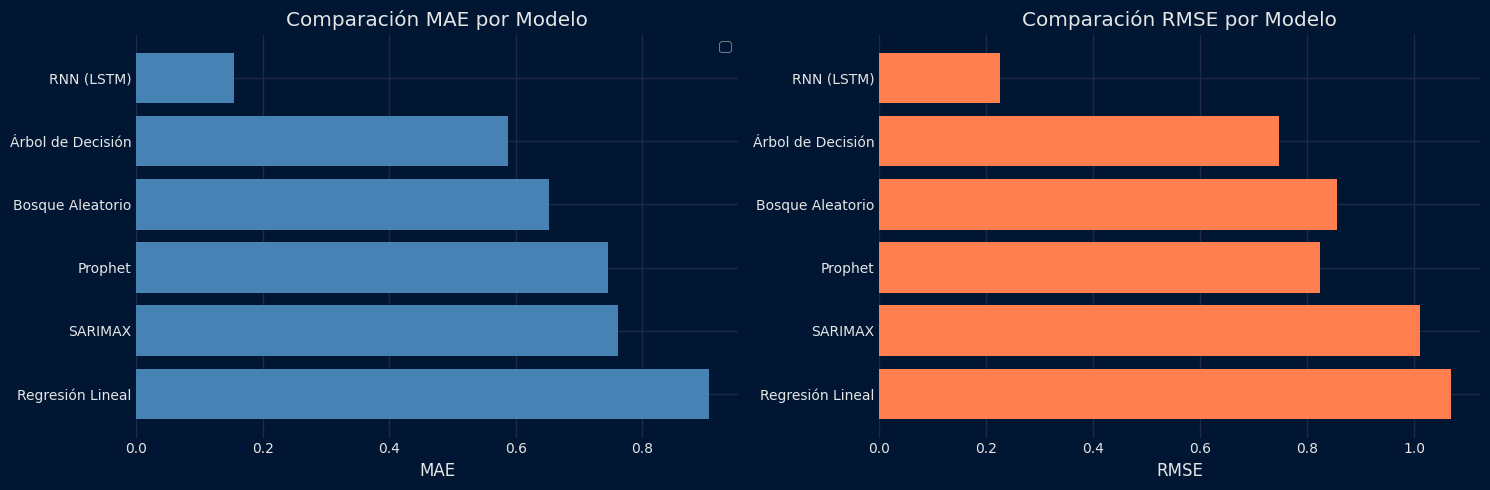

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(resultados["Modelo"], resultados["MAE"], color="steelblue")
axes[0].set_xlabel("MAE")
axes[0].set_title("Comparación MAE por Modelo")
axes[0].legend()
axes[0].invert_yaxis()

axes[1].barh(resultados["Modelo"], resultados["RMSE"], color="coral")
axes[1].set_xlabel("RMSE")
axes[1].set_title("Comparación RMSE por Modelo")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

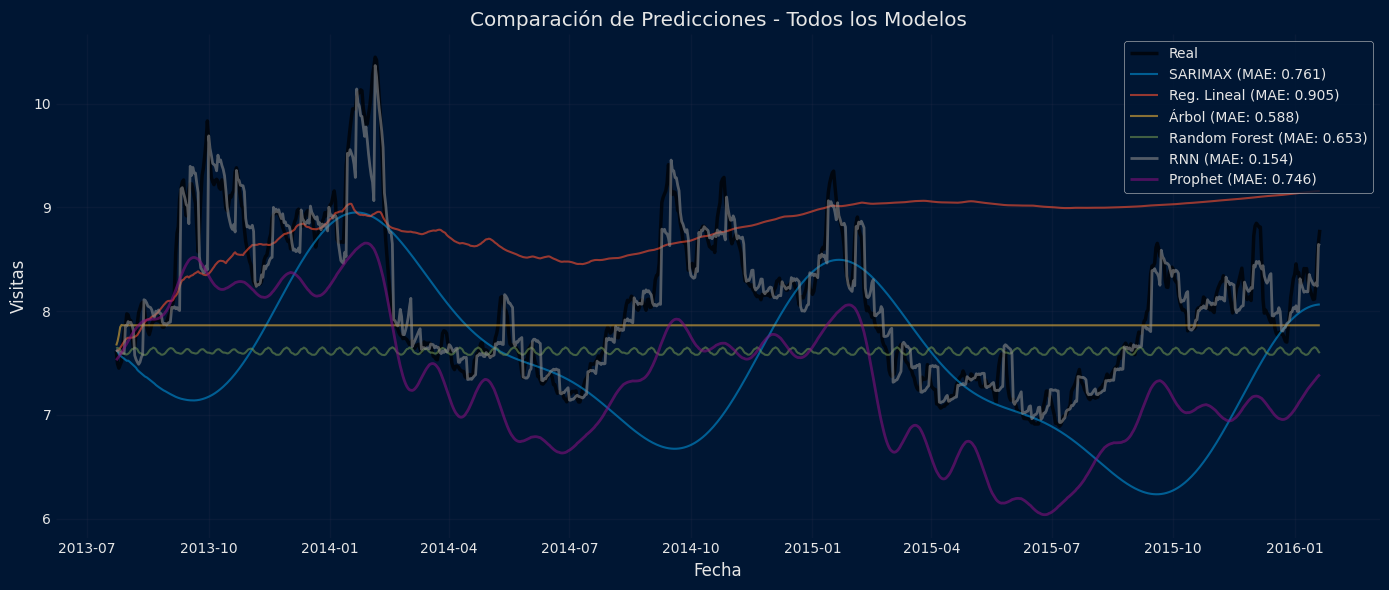

In [32]:
plt.figure(figsize=(14, 6))

plt.plot(
    data_test.index,
    data_test.values,
    label="Real",
    linewidth=2.5,
    color="black",
    alpha=0.7,
)
plt.plot(
    pred_sarimax.index,
    pred_sarimax.values,
    label=f"SARIMAX (MAE: {mae_sarimax:.3f})",
    alpha=0.6,
)
plt.plot(
    pred_lr.index, pred_lr.values, label=f"Reg. Lineal (MAE: {mae_lr:.3f})", alpha=0.6
)
plt.plot(pred_dt.index, pred_dt.values, label=f"Árbol (MAE: {mae_dt:.3f})", alpha=0.6)
plt.plot(
    pred_rf.index, pred_rf.values, label=f"Random Forest (MAE: {mae_rf:.3f})", alpha=0.6
)
plt.plot(
    pred_rnn.index,
    pred_rnn.values,
    label=f"RNN (MAE: {mae_rnn:.3f})",
    alpha=0.6,
    linewidth=2,
)
plt.plot(
    pred_prophet_series.index,
    pred_prophet_series.values,
    label=f"Prophet (MAE: {mae_prophet:.3f})",
    alpha=0.6,
    linewidth=2,
)

plt.legend(loc="best")
plt.title("Comparación de Predicciones - Todos los Modelos")
plt.xlabel("Fecha")
plt.ylabel("Visitas")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


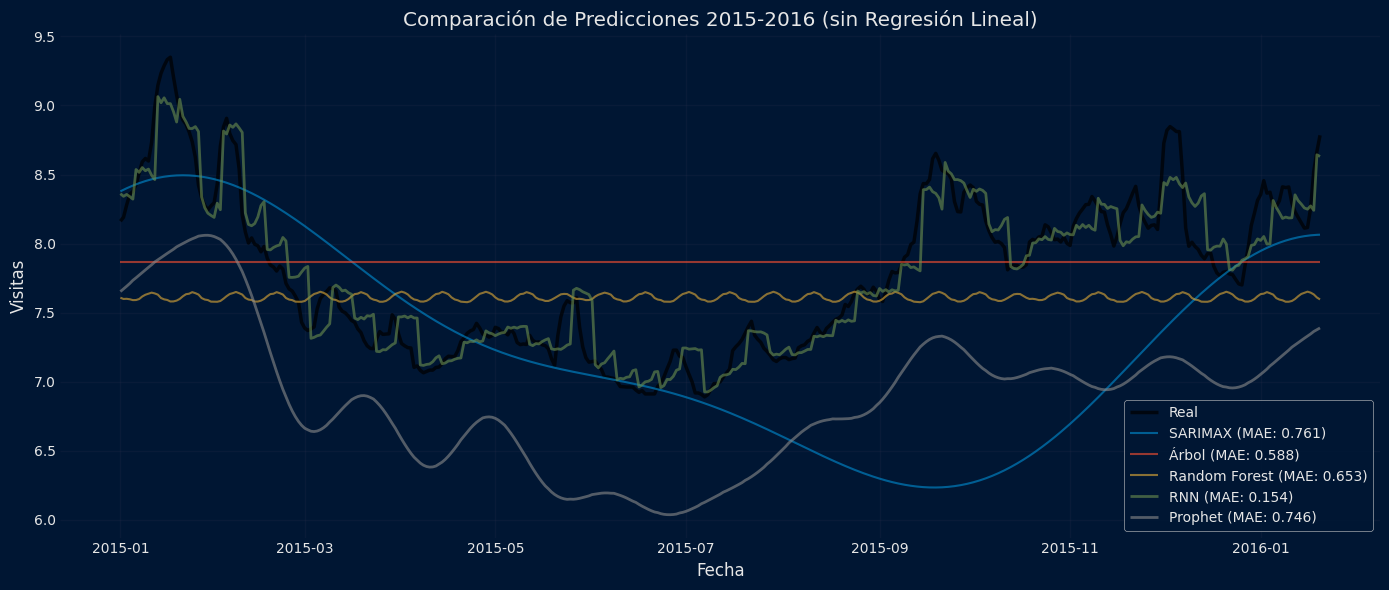

In [33]:
start_date = "2015-01-01"
end_date = "2016-12-31"

mask = (data_test.index >= start_date) & (data_test.index <= end_date)
data_test_zoom = data_test[mask]
pred_sarimax_zoom = pred_sarimax[mask]
pred_dt_zoom = pred_dt[mask]
pred_rf_zoom = pred_rf[mask]
pred_rnn_zoom = pred_rnn[mask]
pred_prophet_series_zoom = pred_prophet_series[mask]

plt.figure(figsize=(14, 6))

plt.plot(
    data_test_zoom.index,
    data_test_zoom.values,
    label="Real",
    linewidth=2.5,
    color="black",
    alpha=0.7,
)
plt.plot(
    pred_sarimax_zoom.index,
    pred_sarimax_zoom.values,
    label=f"SARIMAX (MAE: {mae_sarimax:.3f})",
    alpha=0.6,
)
plt.plot(
    pred_dt_zoom.index,
    pred_dt_zoom.values,
    label=f"Árbol (MAE: {mae_dt:.3f})",
    alpha=0.6,
)
plt.plot(
    pred_rf_zoom.index,
    pred_rf_zoom.values,
    label=f"Random Forest (MAE: {mae_rf:.3f})",
    alpha=0.6,
)
plt.plot(
    pred_rnn_zoom.index,
    pred_rnn_zoom.values,
    label=f"RNN (MAE: {mae_rnn:.3f})",
    alpha=0.6,
    linewidth=2,
)
plt.plot(
    pred_prophet_series_zoom.index,
    pred_prophet_series_zoom.values,
    label=f"Prophet (MAE: {mae_prophet:.3f})",
    alpha=0.6,
    linewidth=2,
)

plt.legend(loc="best")
plt.title("Comparación de Predicciones 2015-2016 (sin Regresión Lineal)")
plt.xlabel("Fecha")
plt.ylabel("Visitas")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Mejor modelo: RNN (LSTM)


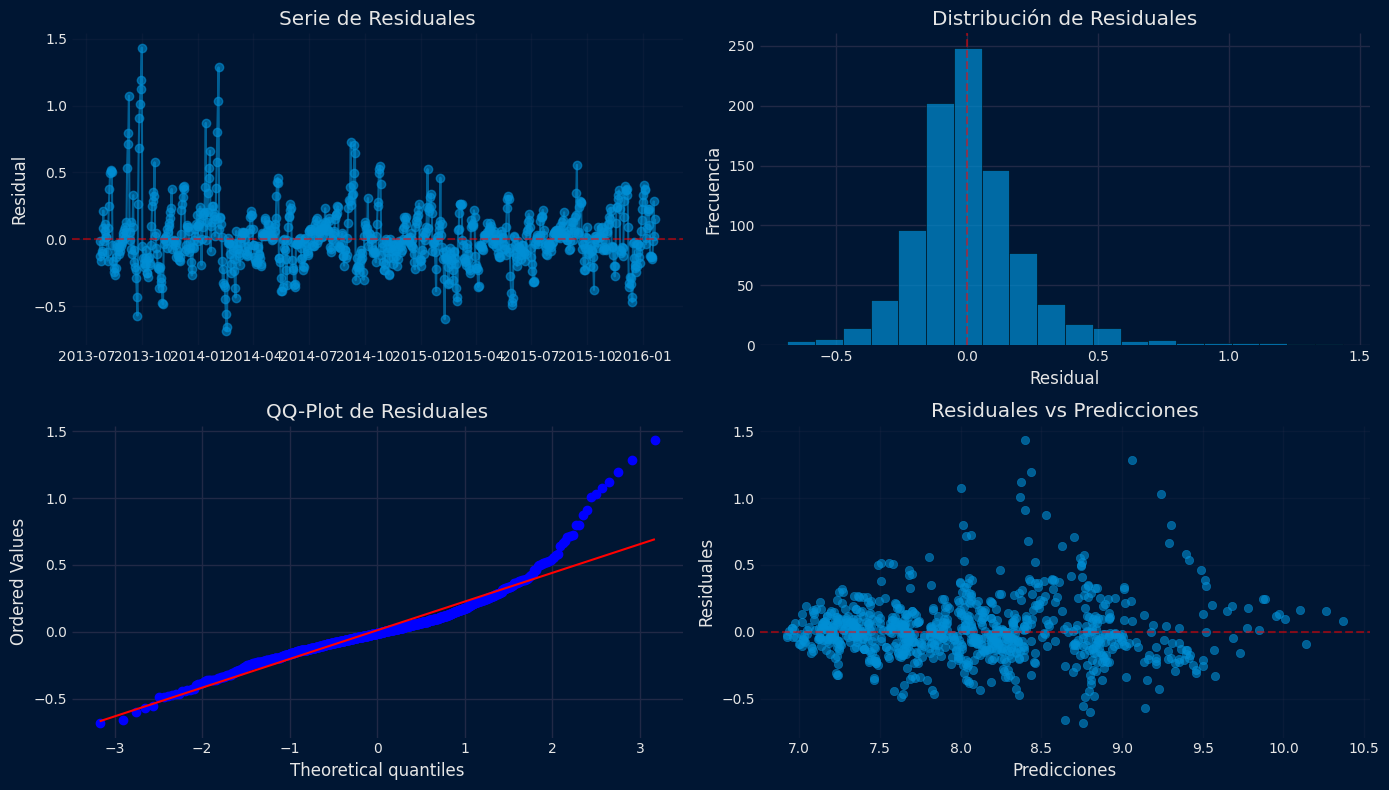


Estadísticas de Residuales (RNN (LSTM)):
Media: 0.0118
Std: 0.2251
Min: -0.6853
Max: 1.4349


In [34]:
mejor_modelo_idx = resultados["MAE"].idxmin()
mejor_modelo = resultados.loc[mejor_modelo_idx, "Modelo"]

print(f"Mejor modelo: {mejor_modelo}")

if mejor_modelo == "SARIMAX":
    pred_mejor = pred_sarimax
elif mejor_modelo == "Regresión Lineal":
    pred_mejor = pred_lr
elif mejor_modelo == "Árbol de Decisión":
    pred_mejor = pred_dt
elif mejor_modelo == "Bosque Aleatorio":
    pred_mejor = pred_rf
elif mejor_modelo == "Prophet":
    pred_mejor = pred_prophet_series
else:
    pred_mejor = pred_rnn

residuales = data_test - pred_mejor

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Serie de residuales
axes[0, 0].plot(residuales, marker="o", linestyle="-", alpha=0.6)
axes[0, 0].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[0, 0].set_title("Serie de Residuales")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].grid(True, alpha=0.3)

# 2. Histograma
axes[0, 1].hist(residuales, bins=20, edgecolor="black", alpha=0.7)
axes[0, 1].axvline(0, color="red", linestyle="--", alpha=0.5)
axes[0, 1].set_title("Distribución de Residuales")
axes[0, 1].set_xlabel("Residual")
axes[0, 1].set_ylabel("Frecuencia")

# 3. QQ-Plot
stats.probplot(residuales, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-Plot de Residuales")

# 4. Residuales vs Predicciones
axes[1, 1].scatter(pred_mejor, residuales, alpha=0.6)
axes[1, 1].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[1, 1].set_title("Residuales vs Predicciones")
axes[1, 1].set_xlabel("Predicciones")
axes[1, 1].set_ylabel("Residuales")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas de residuales
print(f"\nEstadísticas de Residuales ({mejor_modelo}):")
print(f"Media: {residuales.mean():.4f}")
print(f"Std: {residuales.std():.4f}")
print(f"Min: {residuales.min():.4f}")
print(f"Max: {residuales.max():.4f}")
